In [1]:
import sys
import os
import warnings
from dataclasses import dataclass
from functools import cached_property
import numpy as np
# setup work directory
current_dir = os.getcwd()
work_dir = os.path.abspath(os.path.join(current_dir, "../"))
os.chdir(work_dir)
sys.path.append(work_dir)
work_dir

'c:\\Project_HOME\\pyradar'

In [2]:
@dataclass
class ColoradarTI1843BoostConfig:
    numTX: int = 3
    numRX: int = 4
    numChirpsPerFrame: int = 128
    numADCSamples: int = 128
    numVirtualAntennas: int = 12
    adcSampleRate: int = 10666000
    startFrequency: float = 76999999488.0
    idleTime: float = 0.000110000000859
    adcStartTime: float = 7.00000009601e-06
    rampEndTime: float = 1.99999994948e-05
    chirpSlope: float = 1.00000000377e+14
    
    @cached_property
    def adc_scale_factor(self) -> float:
        return 0.01
    
    @cached_property
    def rampDuration(self) -> float:
        return self.rampEndTime - self.adcStartTime  # 13 μs

    @cached_property
    def chirpDuration(self) -> float:
        return self.idleTime + self.rampDuration
    
    @cached_property
    def maxDetRange(self) -> float:
        return (self.adcSampleRate * 3e8) / (2 * self.chirpSlope)

    @cached_property
    def chirpBandwidth(self) -> float:
        return self.chirpSlope * self.rampDuration

    @cached_property
    def centerFrequency(self) -> float:
        return self.startFrequency + 0.5 * self.chirpBandwidth

    @cached_property
    def waveLength(self) -> float:
        return 3e8 / self.centerFrequency
    
    @cached_property
    def sampleTimeArray(self) -> np.ndarray:
        Ts = 1 / self.adcSampleRate
        return np.arange(self.numADCSamples) * Ts

    @cached_property
    def frameShape(self) -> tuple:
        return (self.numTX, self.numRX, self.numChirpsPerFrame, self.numADCSamples, 2)

    
    
    @cached_property
    def tx_rel_poses(self) -> np.ndarray:
        tx_rel_trans = np.array([
            [0, 6, 0],
            [0, 10, 0],
            [0, 8, 2],
        ], dtype=np.float64) * 0.5 * self.waveLength

        tx_rel_poses = np.tile(np.eye(4, dtype=np.float64), (self.numTX, 1, 1))
        tx_rel_poses[:, 0:3, 3:4] = tx_rel_trans[..., np.newaxis]
        return tx_rel_poses
        

    @cached_property
    def rx_rel_poses(self) -> np.ndarray:
        rx_rel_trans = np.array([
            [0, 0, 0],
            [0, 2, 0],
            [0, 4, 0],
            [0, 6, 0],
        ], dtype=np.float64) * 0.5 * self.waveLength
    
        rx_rel_poses = np.tile(np.eye(4, dtype=np.float64), (self.numRX, 1, 1))
        rx_rel_poses[:, 0:3, 3:4] = rx_rel_trans[..., np.newaxis]
        return rx_rel_poses
        

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


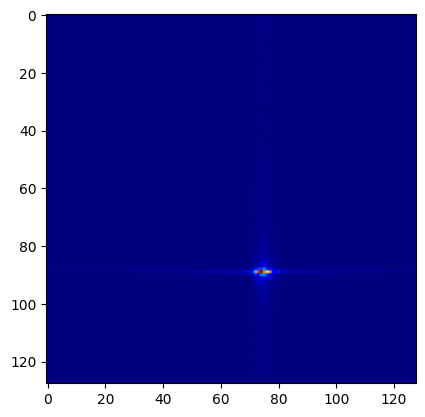

In [3]:
from pyradar_sandbox.sim.demo_sim import generate_sphere_point_cloud, generate_linear_trajectory, radar_simulation, animate_range_images_with_3d
import numpy as np
from pyradar_sandbox.utils.vis import range_doppler_map

import matplotlib.pyplot as plt



radar_config = ColoradarTI1843BoostConfig()
sim_adc = np.zeros((radar_config.numChirpsPerFrame, radar_config.numADCSamples), dtype=np.complex64)  # Simulated ADC output
scene_points, pts_rcs = generate_sphere_point_cloud(center=np.array([10, 1, 0]), radius=1.0)
trajectory = generate_linear_trajectory(n_frames=radar_config.numChirpsPerFrame)
for idxChirp in range(radar_config.numChirpsPerFrame):
    RX_pose = trajectory[idxChirp]  # Get the antenna pose for this chirp
    sim_adc[idxChirp] = radar_simulation(
        scene_points, 
        pts_rcs,
        RX_pose,
        radar_config=radar_config
    )

sim_spectrum = range_doppler_map(adc_cube=sim_adc[..., np.newaxis], IdxChirps=0, IdxSamples=1)  # Take magnitude of the complex ADC output
plt.imshow(np.abs(sim_spectrum), cmap='jet')
plt.show()
